# Automatic laser lock

The notebook is the test UI. Hardware lives in `laserlock/`. The Koheron diode must already be on (`Laser_Power.ipynb`); this notebook does not turn it on or off.

It works very robustly, but there are still some major features needed:

- Needs to be automated, run headless on the rp and not in jupyter notebook (Copy the eventually made script onto the Pitaya (and a venv), then add a systemd service that runs it after boot, e.g. ExecStart=/opt/laserlock/venv/bin/python /opt/laserlock/script.py with WantedBy=multi-user.target, and systemctl enable --now laserlock. From then on, power-cycling the Red Pitaya starts the lock with no host PC involved; use ExecStop to zero OUT1 when the service dies. Use the raspbery pi to start boot the red pitaya)
- Raspberry pi needs to be able to tell the Red pitaya to restart the script at a sensible point in the code to relock. So the red pitaya should be waiting for some signal from the red pitaya. 
- Needs to be able to do a high gain initialization scan, meaning, you will need to build the relay/transitor thing to select which pins on the koheron to bridge, so you can sweep the large portion of the spectrum, identify where you are, and guess the necessary change in RTSET to bring the peak of interest to zero voltage. This is needed because you will find the peak anywhere from RTSET 10390 - 10450 on any given day.
- If you wish to go crazy, you can write custom FPGA bitstream that can implement locking logic in real time instead of recording data and trying to move to the lock point as gently as possible. Linien does this, perhaps you can copy, but I don't recommend. This code's method seems to work for our application. 
- That should be a really good laser locking program!

In [ ]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from laserlock import (
    LaserDrive,
    configure_dither,
    connect,
    disengage_lock,
    engage_i_lock,
    ensure_dither,
    flip_iq_phase,
    open_pid,
    sample_lock_signals,
    set_iq_phase,
    error_scan_window,
    record_dithered_sweep,
    run_fine_scan_and_park,
    silence_feedback,
    triplet_scan_extents,
)
from laserlock.lockpoint import lock_point_from_trace
from laserlock.peaks import analyze_spectrum, plot_peak_analysis


In [155]:
# ------------------------------------------------------------
# User settings — edit here
# ------------------------------------------------------------

HOSTNAME = "rp-f0c970.local"
PYRPL_CONFIG = "my_config"
RELOAD_FPGA = True

IDLE_V = 0.0
LOCK_MIN_V = -1.0
LOCK_MAX_V = +1.0

# Coarse (photodiode survey)
COARSE_START_V = -0.2
COARSE_STOP_V = 0.2
COARSE_SCAN_S = 5.5          # ramp duration
COARSE_SETTLE_S = 0.1        # sit at start before the ramp
PEAK_CHOICE = 2              # 1=left, 2=middle, 3=right
CLUSTER_WINDOW_V = 0.08
REL_PROMINENCE = 0.12
MAX_COARSE_RETRIES = 4

# Same V/s as the coarse ramp; error scans never shorter than 0.20 s
SCAN_RATE_V_S = abs(COARSE_STOP_V - COARSE_START_V) / COARSE_SCAN_S

def scan_s(span_v, min_s=0.20):
    return max(float(min_s), abs(float(span_v)) / SCAN_RATE_V_S)

# Triplet (dithered error through all three lines)
TRIPLET_BELOW_V = 0.060      # padding below the leftmost survey line
TRIPLET_ABOVE_V = 0.10       # padding above the rightmost survey line
TRIPLET_SETTLE_S = 10.0

# Fine (one peak around the triplet lock guess)
FINE_BELOW_V = 0.060        # start = guess − this
FINE_ABOVE_V = 0.1        # stop  = guess + this
FINE_SETTLE_S = 0.0
# A correction shift just in case the fitted lockpoint seems off. Fit 0.232 + 0.005 → park at 0.237.
LOCKPOINT_CORRECTION_V = 0.000

# Dither / IQ
DITHER_FREQUENCY_HZ = 20_000.0
DITHER_AMPLITUDE_V = 0.003
IQ_BANDWIDTH_HZ = 2_000.0
IQ_ACBANDWIDTH_HZ = 1_000.0
LOCKIN_PHASE_DEG = 0.0
QUADRATURE_FACTOR = 10

# PID — PyRPL e = input − setpoint. Loopback sat with I < 0, P = 0.
AUTO_LOCK = True
PID_P = 0.0
PID_I_HZ = -3.0
PID_RAMP_S = 4.0
PID_CORR_MIN_V = -0.20
PID_CORR_MAX_V = +0.20
LOCK_MONITOR_S = 8.0

print(f"Coarse rate {SCAN_RATE_V_S:.3f} V/s  ({COARSE_START_V:+.2f} → {COARSE_STOP_V:+.2f} V in {COARSE_SCAN_S:.2f} s)")
print(f"Settles: coarse {COARSE_SETTLE_S:.2f} s,  triplet {TRIPLET_SETTLE_S:.2f} s,  fine {FINE_SETTLE_S:.2f} s")
print(f"Lockpoint correction {LOCKPOINT_CORRECTION_V:+.6f} V")


Coarse rate 0.073 V/s  (-0.20 → +0.20 V in 5.50 s)
Settles: coarse 0.10 s,  triplet 10.00 s,  fine 0.00 s
Lockpoint correction +0.000000 V


In [ ]:
# ------------------------------------------------------------
# Connect
# ------------------------------------------------------------
p, rp = connect(
    hostname=HOSTNAME,
    config=PYRPL_CONFIG,
    reloadfpga=RELOAD_FPGA,
    gui=False,
)
drive = LaserDrive(rp, idle_v=IDLE_V)
drive.enable_idle()
print(f"ASG points {drive.asg.data_length},  scope points {drive.scope.data_length}")


INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...
  hostname:    rp-f0c970.local
  config:      my_config
  user_dir:    /Users/brandon/Documents/Python Scripts/Grok Laser/pyrpl_data
  reloadfpga:  True
  Flashing the PyRPL FPGA (stock Red Pitaya image will not work). ~10 s...


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


  FPGA overlay file: cat /tmp/loaded_fpga.inf
Connected. Analog outputs are disconnected until the laser drive enables OUT1.
OUT1 enabled, parked at +0.0000 V.
Scope warmup: 32768 samples (discarded)
ASG points 16384,  scope points 16384


## AOM on OUT2

Continuous sine on **OUT2** (`asg1`) for the AOM. Stays on until **Shutdown**.


In [157]:
# ------------------------------------------------------------
# AOM drive — OUT2 / asg1. Leave running until shutdown.
# ------------------------------------------------------------

AOM_FREQUENCY_HZ = (115.325/4)*1e6
AOM_AMPLITUDE_V = 1.0  # peak volts, max 1.0

drive.start_aom(AOM_FREQUENCY_HZ, AOM_AMPLITUDE_V)


AOM OUT2: 28.831250 MHz  (requested 28.831250 MHz)  amp 1.0000 V peak  output_direct=out2


## Coarse scan

Sit **0.1 s** at the low start, then a ramp. Idle at 0 V after the ramp. Peak finder labels the L→R triplet; `PEAK_CHOICE` selects which line to follow.



------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.2000 V
Scan:      -0.200000 -> +0.200000 V
Scan time: 5.500 s
ASG period: 8.590 s   scope window 8.590 s  (decimation 65536)
Pause:     0.100 s
Holding +0.0000 V
Scan samples: 9546  (raw window 9651)
Kept voltage: -0.195967 -> +0.167964 V  (requested -0.200000 -> +0.200000 V)
Now holding:  +0.000000 V


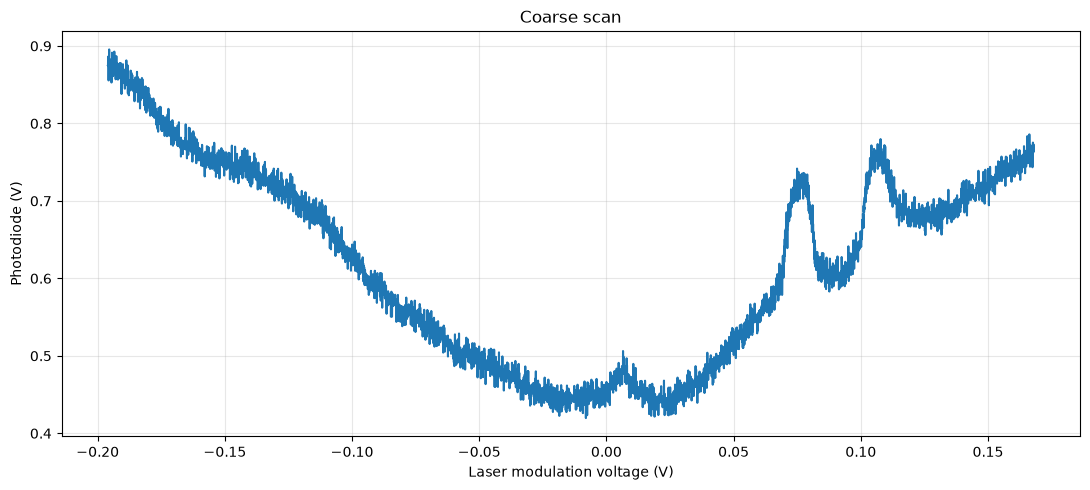

Holding +0.0000 V


In [158]:
# ------------------------------------------------------------
# Coarse scan
# ------------------------------------------------------------

silence_feedback(rp)
coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
    start_v=COARSE_START_V,
    stop_v=COARSE_STOP_V,
    scan_time=COARSE_SCAN_S,
    pause_s=COARSE_SETTLE_S,
)

plt.figure(figsize=(11, 5))
plt.plot(coarse_x, coarse_pd)
plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode (V)")
plt.title("Coarse scan")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Holding {drive.current_v:+.4f} V")


Triplet (left to right):
  1: +0.006563 V   prom 0.06182
  2: +0.075265 V   prom 0.1252  <-- selected
  3: +0.107473 V   prom 0.11
Target (peak 2): +0.075265 V


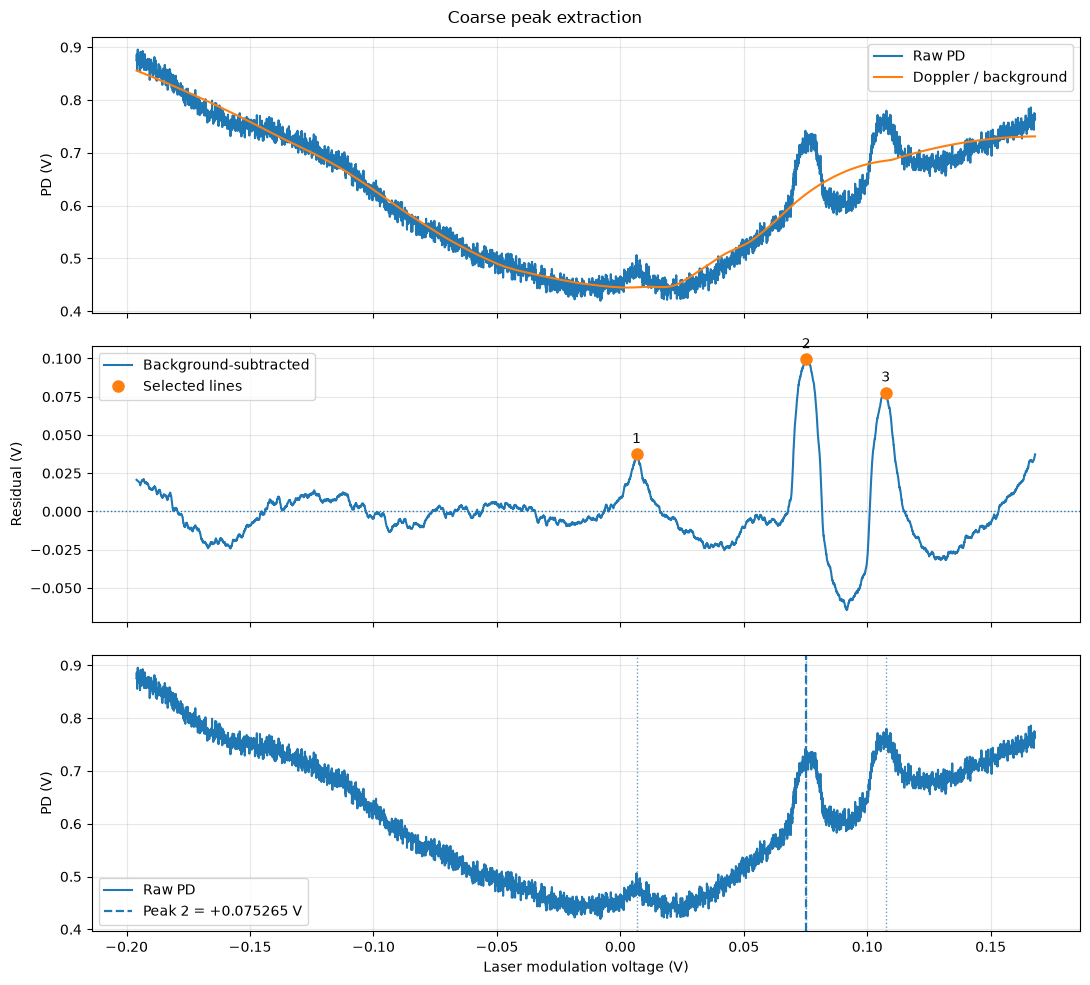

In [159]:
# ------------------------------------------------------------
# Coarse peak ID
# ------------------------------------------------------------

analysis = None
for attempt in range(1, MAX_COARSE_RETRIES + 1):
    if attempt > 1:
        print(f"Attempt {attempt}: no triplet. Rescanning.")
        coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
            start_v=COARSE_START_V,
            stop_v=COARSE_STOP_V,
            scan_time=COARSE_SCAN_S,
            pause_s=COARSE_SETTLE_S,
        )
    analysis = analyze_spectrum(
        coarse_x,
        coarse_pd,
        peak_choice=PEAK_CHOICE,
        cluster_window_v=CLUSTER_WINDOW_V,
        rel_prominence=REL_PROMINENCE,
    )
    if analysis["ok"]:
        break
else:
    plot_peak_analysis(coarse_x, coarse_pd, analysis, title="Coarse — triplet not found")
    raise RuntimeError("Coarse scan did not show three sub-Doppler peaks.")

print("Triplet (left to right):")
for pk in analysis["triplet"]:
    mark = "  <-- selected" if pk is analysis["target"] else ""
    print(f"  {pk['label']}: {pk['voltage']:+.6f} V   prom {pk['prominence']:.4g}{mark}")

v_target = analysis["target"]["voltage"]
print(f"Target (peak {PEAK_CHOICE}): {v_target:+.6f} V")
plot_peak_analysis(coarse_x, coarse_pd, analysis, title="Coarse peak extraction")


## Triplet scan

Dither on. Sit at a voltage below the leftmost survey line for stability, then an uphill error ramp through all three lines. Jump back to that start immediately. Lock guess = S-curve nearest the selected coarse peak.


Peak 2 at +0.075265 V   window -0.053437 → +0.207473 V   ramp 3.588 s  (0.073 V/s)
Dither on, PID open.
  0.0030 V @ 20000.0 Hz, phase 0.0 deg

Error-scan reference: +0.075265 V
Window: -0.053437 -> +0.207473 V
Scan start: +0.000000 -> -0.053437 V  (Δ 53.4 mV)
Slew +0.0000 V -> -0.0534 V in 0.214 s

------------------------------------------------------------
TRIPLET SCAN (analog ramp, record IN1 + iq0)
------------------------------------------------------------
Holding -0.0534 V
Sitting 10.000 s at start...
Scan:      -0.053437 -> +0.207473 V
Scan time: 3.588 s
Sit start: 10.000 s
Window:    4.295 s  (decimation 32768)
Holding -0.0534 V
Returned to start -0.053437 V (low-V side; do not sit at the high endpoint)
Scan samples: 12864  (raw window 13001)
Kept voltage: -0.050810 -> +0.194411 V  (requested -0.053437 -> +0.207473 V)
Now holding:  -0.053437 V
PD ptp 0.4316 V,  |error| max 0.1603 V
S-curves: 2 at +0.0679 V, +0.1052 V
LOCK GUESS +0.069751 V   (mid-height +0.0137 V,  span 9.5 m

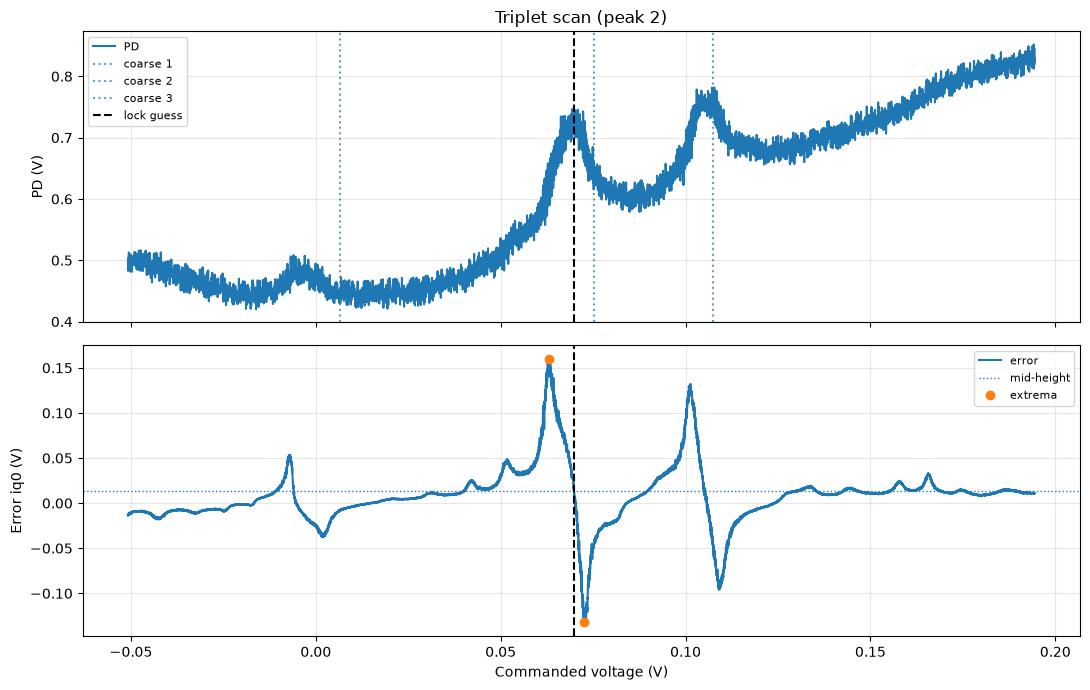

Holding triplet start -0.053437 V


In [160]:
# ------------------------------------------------------------
# Triplet scan
# ------------------------------------------------------------

below, above = triplet_scan_extents(
    analysis["triplet"],
    v_target,
    below_v=TRIPLET_BELOW_V,
    above_v=TRIPLET_ABOVE_V,
)
t_start, t_stop = error_scan_window(v_target, below, above, LOCK_MIN_V, LOCK_MAX_V)
triplet_scan_s = scan_s(t_stop - t_start)
print(
    f"Peak {PEAK_CHOICE} at {v_target:+.6f} V   "
    f"window {t_start:+.6f} → {t_stop:+.6f} V   "
    f"ramp {triplet_scan_s:.3f} s  ({abs(t_stop-t_start)/triplet_scan_s:.3f} V/s)"
)

silence_feedback(rp)
configure_dither(
    rp,
    frequency_hz=DITHER_FREQUENCY_HZ,
    amplitude_v=DITHER_AMPLITUDE_V,
    bandwidth_hz=IQ_BANDWIDTH_HZ,
    acbandwidth_hz=IQ_ACBANDWIDTH_HZ,
    phase_deg=LOCKIN_PHASE_DEG,
    quadrature_factor=QUADRATURE_FACTOR,
    pid_corr_min_v=PID_CORR_MIN_V,
    pid_corr_max_v=PID_CORR_MAX_V,
)

triplet = record_dithered_sweep(
    drive,
    rp,
    v_peak=v_target,
    below_v=below,
    above_v=above,
    scan_time=triplet_scan_s,
    pause_s=TRIPLET_SETTLE_S,
    lock_min_v=LOCK_MIN_V,
    lock_max_v=LOCK_MAX_V,
    name="TRIPLET SCAN",
)

guess_lp = lock_point_from_trace(
    triplet["voltage"],
    triplet["error"],
    hint_voltage=v_target,
    peak_choice=PEAK_CHOICE,
)
lock_guess = guess_lp["lock_voltage"]
print(
    f"S-curves: {guess_lp['n_scurves']} at "
    + ", ".join(f"{c:+.4f} V" for c in guess_lp["scurve_centers"])
)
print(
    f"LOCK GUESS {lock_guess:+.6f} V   "
    f"(mid-height {guess_lp['mean_error']:+.4f} V,  "
    f"span {1e3 * guess_lp['span_v']:.1f} mV)"
)
if abs(lock_guess - v_target) > 0.020:
    print(f"WARNING: guess is {1e3 * (lock_guess - v_target):+.1f} mV from survey peak {PEAK_CHOICE}.")

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
v, e, pd = triplet["voltage"], triplet["error"], triplet["pd"]
axes[0].plot(v, pd, label="PD")
for pk in analysis["triplet"]:
    axes[0].axvline(pk["voltage"], linestyle=":", alpha=0.7, label=f"coarse {pk['label']}")
axes[0].axvline(lock_guess, linestyle="--", color="k", label="lock guess")
axes[0].set_ylabel("PD (V)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(f"Triplet scan (peak {PEAK_CHOICE})")
axes[1].plot(v, e, label="error")
axes[1].axhline(guess_lp["mean_error"], linestyle=":", linewidth=1, label="mid-height")
axes[1].axvline(lock_guess, linestyle="--", color="k")
axes[1].plot(
    [v[guess_lp["min_idx"]], v[guess_lp["max_idx"]]],
    [e[guess_lp["min_idx"]], e[guess_lp["max_idx"]]],
    "o",
    label="extrema",
)
axes[1].set_xlabel("Commanded voltage (V)")
axes[1].set_ylabel("Error iq0 (V)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Holding triplet start {drive.current_v:+.6f} V")


## Fine scan

Sit at (guess − `FINE_BELOW_V`) for stability reasons, ramp uphill at the coarse V/s through (guess + `FINE_ABOVE_V`), jump back to start, then immediately ramp start → lock at that same V/s. `LOCKPOINT_CORRECTION_V` is added if necessary to add a small bump to the voltage from the fitted/guessed location.


Fine window +0.009751 → +0.169751 V   ramp 2.200 s  (0.073 V/s)

------------------------------------------------------------
FINE SCAN — then park at lock
------------------------------------------------------------

Error-scan reference: +0.069751 V
Window: +0.009751 -> +0.169751 V
Scan start: -0.053437 -> +0.009751 V  (Δ 63.2 mV)
Slew -0.0534 V -> +0.0098 V in 0.253 s

------------------------------------------------------------
FINE SCAN (analog ramp, record IN1 + iq0)
------------------------------------------------------------
Holding +0.0098 V
Sitting 0.000 s at start...
Scan:      +0.009751 -> +0.169751 V
Scan time: 2.200 s
Sit start: 0.000 s
Window:    4.295 s  (decimation 32768)
Holding +0.0098 V
Returned to start +0.009751 V (low-V side; do not sit at the high endpoint)
Scan samples: 7889  (raw window 7973)
Kept voltage: +0.011359 -> +0.161732 V  (requested +0.009751 -> +0.169751 V)
Now holding:  +0.009751 V
PD ptp 0.3676 V,  |error| max 0.1224 V
Fine-scan lock +0.068206 V  

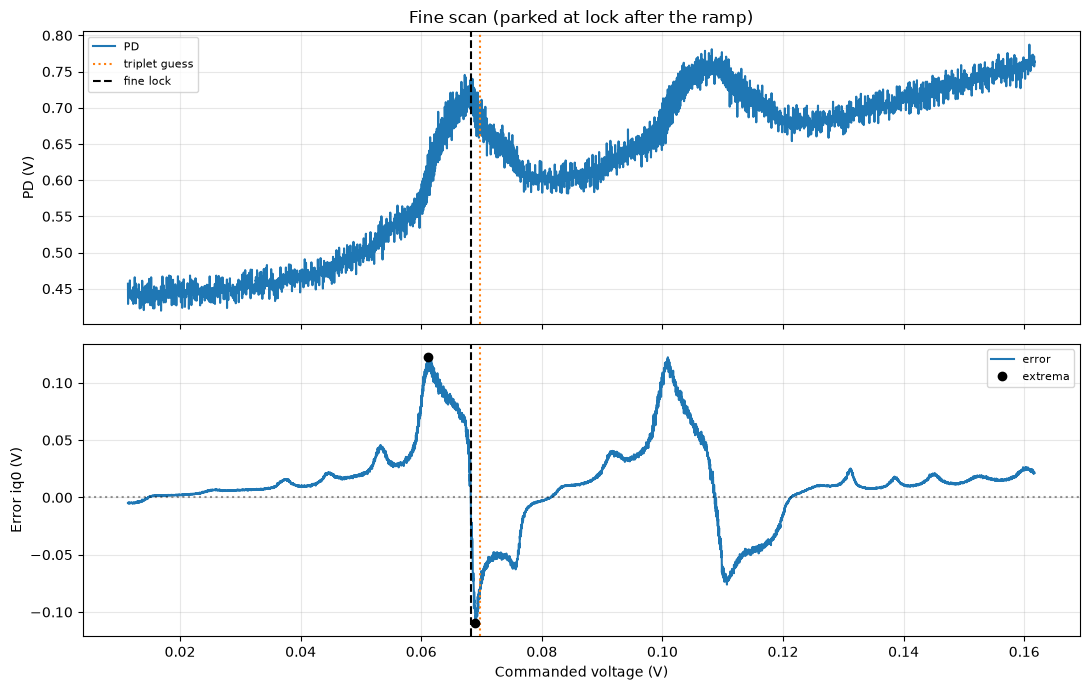

Parked at +0.068206 V  (drive +0.068206 V)


In [161]:
# ------------------------------------------------------------
# Fine scan, then park at the lock point
# ------------------------------------------------------------

f_start, f_stop = error_scan_window(
    lock_guess, FINE_BELOW_V, FINE_ABOVE_V, LOCK_MIN_V, LOCK_MAX_V
)
fine_scan_s = scan_s(f_stop - f_start)
print(
    f"Fine window {f_start:+.6f} → {f_stop:+.6f} V   "
    f"ramp {fine_scan_s:.3f} s  ({abs(f_stop-f_start)/fine_scan_s:.3f} V/s)"
)

fine, lp = run_fine_scan_and_park(
    drive,
    rp,
    v_guess=lock_guess,
    below_v=FINE_BELOW_V,
    above_v=FINE_ABOVE_V,
    scan_time=fine_scan_s,
    pause_s=FINE_SETTLE_S,
    lock_min_v=LOCK_MIN_V,
    lock_max_v=LOCK_MAX_V,
    correction_v=LOCKPOINT_CORRECTION_V,
)
lock_voltage = lp["lock_voltage"]
lock_fit = lp.get("lock_voltage_fit", lock_voltage)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(fine["voltage"], fine["pd"], label="PD")
axes[0].axvline(lock_guess, linestyle=":", color="C1", label="triplet guess")
if abs(lock_voltage - lock_fit) > 1e-9:
    axes[0].axvline(lock_fit, linestyle=":", color="0.5", label="fit")
axes[0].axvline(lock_voltage, linestyle="--", color="k", label="fine lock")
axes[0].set_ylabel("PD (V)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Fine scan (parked at lock after the ramp)")
axes[1].plot(fine["voltage"], fine["error"], label="error")
axes[1].axvline(lock_guess, linestyle=":", color="C1")
if abs(lock_voltage - lock_fit) > 1e-9:
    axes[1].axvline(lock_fit, linestyle=":", color="0.5")
axes[1].axvline(lock_voltage, linestyle="--", color="k")
axes[1].axhline(0.0, linestyle=":", color="k", alpha=0.4)
axes[1].plot(
    [fine["voltage"][lp["min_idx"]], fine["voltage"][lp["max_idx"]]],
    [fine["error"][lp["min_idx"]], fine["error"][lp["max_idx"]]],
    "o",
    color="k",
    label="extrema",
)
axes[1].set_xlabel("Commanded voltage (V)")
axes[1].set_ylabel("Error iq0 (V)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Parked at {lock_voltage:+.6f} V  (drive {drive.current_v:+.6f} V)")


## PID

In [ ]:
# ------------------------------------------------------------
# PID - The best settings are LOCKIN_PHASE_DEG = 180.0, P=-0.1, I=-20.0 Hz, D=0.0. (but they can easily be adjusted and still work, perhaps you can even improve)
# ------------------------------------------------------------

LOCKIN_PHASE_DEG = 180.0
PID_P = -0.1
PID_I_HZ = -20.0

open_pid(rp)
set_iq_phase(rp, LOCKIN_PHASE_DEG)
ensure_dither(rp)

sig0 = sample_lock_signals(rp, t=0.05)
print(f"Before PID  asg0={drive.current_v:+.6f}  out1={sig0['out1']:+.4f}  "
      f"err={sig0['error']:+.4f}  PD={sig0['pd']:+.4f}")
if "lock_voltage" in dir():
    print(f"  fine-scan lock point {lock_voltage:+.6f} V  "
          f"(park vs lock {1e3*(drive.current_v-lock_voltage):+.1f} mV)")
if abs(sig0["error"]) > 0.01:
    print("  WARNING: error is not near 0 at park — PID will servo to a different zero.")

pid = rp.pid0
if hasattr(pid, "paused"):
    pid.paused = False
pid.inputfilter = [0, 0, 0, 0]
pid.input = "iq0"
pid.setpoint = 0.0
pid.ival = 0.0
if hasattr(pid, "max_voltage"):
    pid.max_voltage = float(PID_CORR_MAX_V)
    pid.min_voltage = float(PID_CORR_MIN_V)
pid.output_direct = "out1"
pid.p = float(PID_P)
pid.i = float(PID_I_HZ)
print(f"PID on  P={pid.p:g}  I={pid.i:g} Hz  phase={float(rp.iq0.phase):.1f} deg")
print("t     ival      out1      err       PD")
for k in range(6):
    time.sleep(0.4)
    sig = sample_lock_signals(rp, t=0.04)
    print(
        f"{0.4*(k+1):3.1f}  {float(pid.ival):+.4f}  {sig['out1']:+.4f}  "
        f"{sig['error']:+.4f}  {sig['pd']:+.4f}"
    )


PID open. Dither still on; ASG still at the park.
IQ phase 180.0 deg
Dither: 0.0030 V @ 20000 Hz  output_direct=out1  on=True
  OUT1 while parked: std 2.14 mV,  ptp 5.74 mV  (2 mV amp dither is ~4 mVpp if present)
Before PID  asg0=+0.068206  out1=+0.0681  err=-0.0791  PD=+0.5833
  fine-scan lock point +0.068206 V  (park vs lock +0.0 mV)
PID on  P=-0.100098  I=-20.0011 Hz  phase=180.0 deg
t     ival      out1      err       PD
0.4  +0.0048  +0.0729  +0.0001  +0.7209
0.8  +0.0051  +0.0736  +0.0004  +0.7218
1.2  +0.0059  +0.0729  +0.0000  +0.7242
1.6  +0.0065  +0.0739  +0.0003  +0.7224
2.0  +0.0078  +0.0750  +0.0008  +0.7144
2.4  +0.0066  +0.0743  +0.0006  +0.7170


In [ ]:
# # ------------------------------------------------------------
# # Open PID — (uncomment to stop PID, laser will drift away)
# # ------------------------------------------------------------

# open_pid(rp)


PID open. Dither still on; ASG still at the park.


In [ ]:
# # ------------------------------------------------------------
# # Shutdown — zeros PID/IQ, slews ASG to 0 V, disconnects OUT1
# # ------------------------------------------------------------

# drive.shutdown()


Shutdown: disconnect PID/IQ from OUT1, then slew ASG to idle.
AOM OUT2 off.
Slew +0.0682 V -> +0.0000 V in 1.500 s
OUT1 after slew (ASG still connected): +0.0 mV  ptp 0.0 mV
OUT1 after ASG disconnect: +0.0 mV  ptp 0.0 mV
OUT1 routes:
  asg0.output_direct=off
  asg1.output_direct=off
  pid0.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  pid1.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  pid2.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  iq0.output_direct=off  amp=0.0000
  iq1.output_direct=off  amp=0.0000
  iq2.output_direct=off  amp=0.0000
Shutdown done. ASG disconnected.
